In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

In [ ]:
path=r"/content/3TIB_06_GenzCyberResilience.xlsx"
dataraw=pd.read_excel(path, sheet_name="Data")
print(dataraw)
print("Jumlah data kosong:", dataraw.isna().sum().sum())
print(dataraw["Gender"].value_counts())

     ID_Responden  Gender           Occupation         Education_Level  \
0               1    Male              Student           Undergraduate   
1               2    Male              Student  High School/Equivalent   
2               3  Female              Student  High School/Equivalent   
3               4    Male              Student  High School/Equivalent   
4               5    Male              Student  High School/Equivalent   
..            ...     ...                  ...                     ...   
395           396    Male  Government Employee  High School/Equivalent   
396           397    Male  Government Employee           Undergraduate   
397           398    Male  Government Employee  High School/Equivalent   
398           399    Male  Government Employee  High School/Equivalent   
399           400    Male              Student  High School/Equivalent   

    Platform_Count Main_Platform Daily_Duration             Primary_Purpose  \
0    2-3 Platforms     Instagram

In [ ]:
for k in ["BMS","PKS","MPK"]:
    kolom=[c for c in dataraw.columns if c.startswith(k)]
    dataraw[k]=dataraw[kolom].mean(axis=1)
    print(k, len(kolom), "data")
print(dataraw[["BMS","PKS","MPK"]].head())

BMS 16 data
PKS 18 data
MPK 13 data
        BMS       PKS       MPK
0  1.000000  4.705882  1.000000
1  3.666667  3.882353  3.916667
2  5.000000  5.000000  5.000000
3  4.333333  3.647059  3.500000
4  1.600000  4.470588  1.166667


In [ ]:
batas=[1, 7/3, 11/3, 5]
label=["Rendah","Sedang","Tinggi"]
for k in ["BMS","PKS","MPK"]:
    dataraw[k+"_kat"]=pd.cut(dataraw[k], bins=batas, labels=label, include_lowest=True)

datafrq=pd.DataFrame({k: dataraw[k+"_kat"].value_counts().reindex(label) for k in ["BMS","PKS","MPK"]})
print(datafrq)
print((datafrq/len(dataraw)*100).round(1))

        BMS  PKS  MPK
Rendah   78    3   53
Sedang  247  221  255
Tinggi   75  176   92
         BMS   PKS   MPK
Rendah  19.5   0.8  13.2
Sedang  61.8  55.2  63.7
Tinggi  18.8  44.0  23.0


In [ ]:
hasil=pd.DataFrame()
for k in ["BMS","PKS","MPK"]:
    dt=dataraw[k]
    stats=dt.describe()
    stats['Median']= dt.median()
    stats['Mode']= dt.round(1).mode().iloc[0]
    stats['variance']= dt.var()
    stats['range']= dt.max()-dt.min()
    stats['skewness']= dt.skew()
    stats['kurtosis']= dt.kurtosis()
    hasil[k]=stats
print(hasil.round(3))

              BMS      PKS      MPK
count     400.000  400.000  400.000
mean        3.019    3.629    3.166
std         0.807    0.588    0.786
min         1.000    1.471    1.000
25%         2.600    3.176    2.833
50%         3.000    3.588    3.000
75%         3.467    4.000    3.667
max         5.000    5.000    5.000
Median      3.000    3.588    3.000
Mode        3.000    3.100    3.000
variance    0.651    0.346    0.618
range       4.000    3.529    4.000
skewness    0.049    0.206   -0.050
kurtosis    0.337    0.373    0.617


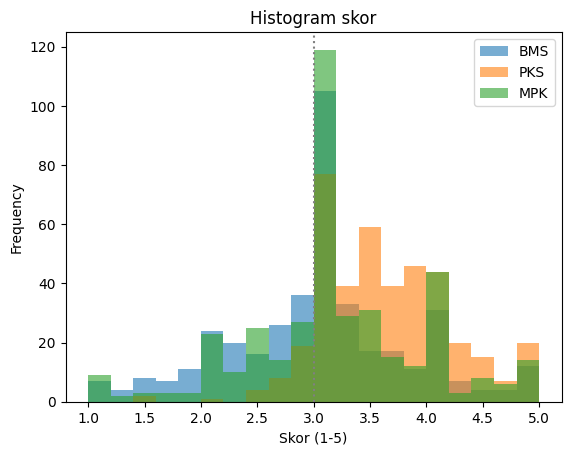

In [ ]:
dataraw[["BMS","PKS","MPK"]].plot(kind='hist', bins=20, alpha=0.6, title="Histogram skor")
plt.axvline(3, color="gray", ls=":")
plt.xlabel("Skor (1-5)")
plt.show()

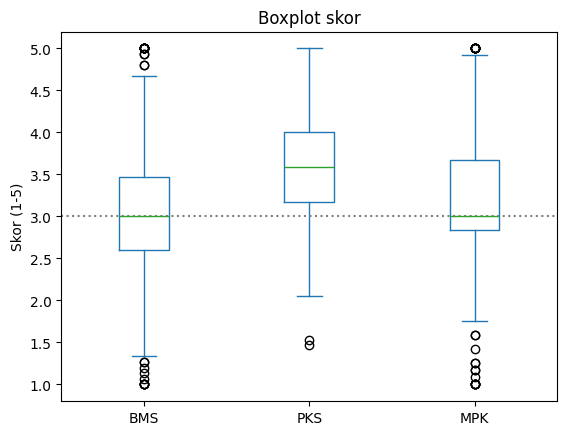

In [ ]:
dataraw[["BMS","PKS","MPK"]].plot(kind='box', title="Boxplot skor")
plt.axhline(3, color="gray", ls=":")
plt.ylabel("Skor (1-5)")
plt.show()

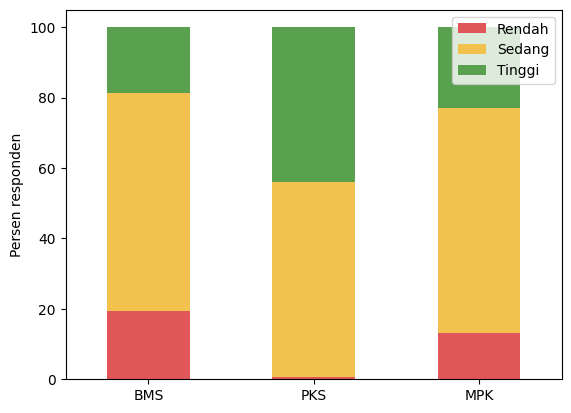

In [ ]:
(datafrq/len(dataraw)*100).T.plot(kind='bar', stacked=True, color=["#e15759","#f2c14e","#59a14f"])
plt.ylabel("Persen responden")
plt.xticks(rotation=0)
plt.show()

BMS W = 0.9746 p = 1.81e-06 -> TIDAK normal
PKS W = 0.974 p = 1.42e-06 -> TIDAK normal
MPK W = 0.9651 p = 3.69e-08 -> TIDAK normal


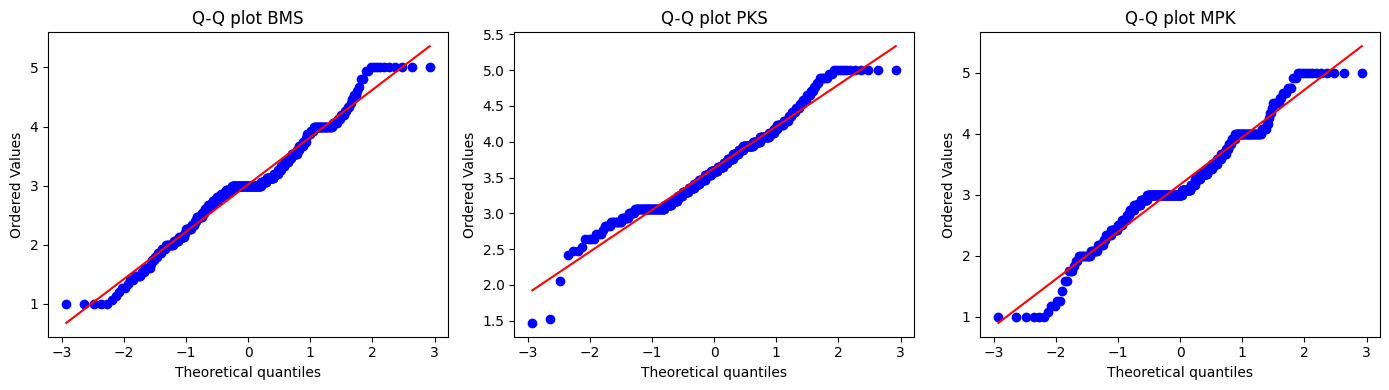

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, k in zip(ax, ["BMS","PKS","MPK"]):
    w, p = st.shapiro(dataraw[k])
    print(k, "W =", round(w,4), "p =", f"{p:.2e}", "->", "normal" if p>=0.05 else "TIDAK normal")
    st.probplot(dataraw[k], dist="norm", plot=a)
    a.set_title("Q-Q plot "+k)
plt.tight_layout()
plt.show()

In [ ]:
for k in ["BMS","PKS","MPK"]:
  w, p = st.wilcoxon(dataraw[k]-3)
  t, pt = st.ttest_1samp(dataraw[k], 3)
  print(k, "mean =", round(dataraw[k].mean(),3), "| Wilcoxon p =", f"{p:.4g}", "| uji-t p =", f"{pt:.4g}")

BMS mean = 3.019 | Wilcoxon p = 0.6534 | uji-t p = 0.635
PKS mean = 3.629 | Wilcoxon p = 7.885e-55 | uji-t p = 3.097e-68
MPK mean = 3.166 | Wilcoxon p = 1.06e-05 | uji-t p = 2.834e-05


In [ ]:
#Korelasi Spearman
rho, p_rho = st.spearmanr(dataraw["BMS"], dataraw["PKS"])
print("Spearman BMS-PKS: rho =", round(rho,3), "p =", round(p_rho,4))

#Korelasi antar tiga skor
print(dataraw[["BMS","PKS","MPK"]].corr(method="spearman").round(3))

#Regresi Linear Sederhana
reg = st.linregress(dataraw["BMS"], dataraw["PKS"])
print("PKS =", round(reg.intercept,3), "+", round(reg.slope,3), "* BMS")
print("R2 =", round(reg.rvalue**2,3), "| p =", round(reg.pvalue,4))

Spearman BMS-PKS: rho = 0.088 p = 0.0794
       BMS    PKS    MPK
BMS  1.000  0.088  0.734
PKS  0.088  1.000  0.244
MPK  0.734  0.244  1.000
PKS = 3.36 + 0.089 * BMS
R2 = 0.015 | p = 0.0142


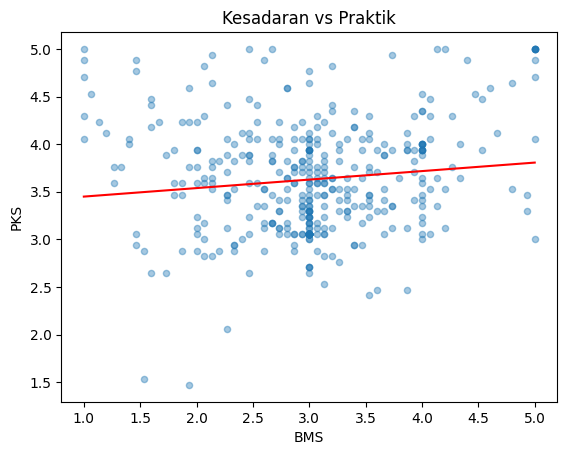

In [ ]:
dataraw.plot(kind='scatter', x="BMS", y="PKS", alpha=0.4, title="Kesadaran vs Praktik")
x=np.array([1,5])
plt.plot(x, reg.intercept+reg.slope*x, color="red")
plt.show()

In [ ]:
for k in ["BMS","PKS","MPK"]:
    L=dataraw.loc[dataraw["Gender"]=="Male", k]
    P=dataraw.loc[dataraw["Gender"]=="Female", k]
    u, p = st.mannwhitneyu(L, P, alternative="two-sided")
    print(k, "mean L =", round(L.mean(),3), "| mean P =", round(P.mean(),3), "| p =", round(p,4))

BMS mean L = 3.074 | mean P = 2.91 | p = 0.1027
PKS mean L = 3.668 | mean P = 3.55 | p = 0.0671
MPK mean L = 3.235 | mean P = 3.029 | p = 0.01


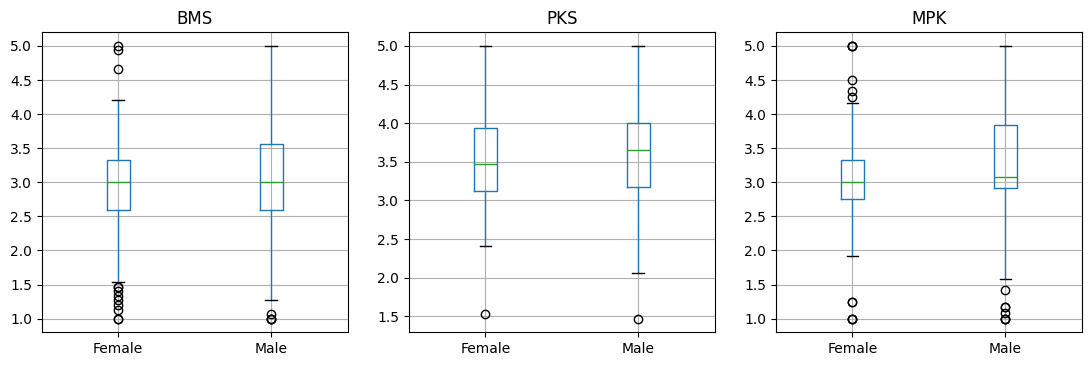

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, k in zip(ax, ["BMS","PKS","MPK"]):
    dataraw.boxplot(column=k, by="Gender", ax=a)
    a.set_title(k); a.set_xlabel("")
plt.suptitle("")
plt.show()

p(Tinggi) = 0.1875
     k  P(X=k)
0    0  0.1254
1    1  0.2893
2    2  0.3005
3    3  0.1849
4    4  0.0747
5    5  0.0207
6    6  0.0040
7    7  0.0005
8    8  0.0000
9    9  0.0000
10  10  0.0000
P(X>=7) = 0.0006
Mean = 1.88 | SD = 1.23


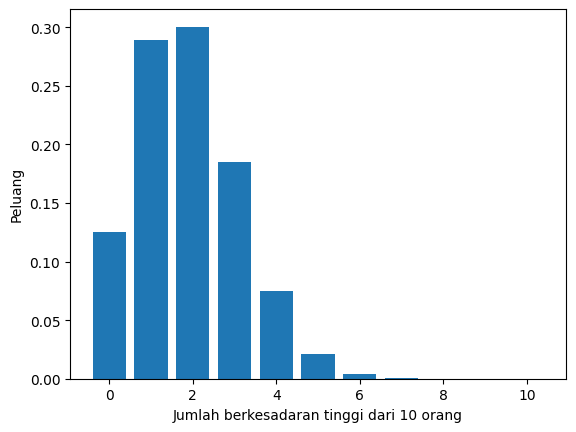

In [ ]:
p_hat=(dataraw["BMS_kat"]=="Tinggi").mean()
n=10
x=np.arange(0, n+1)
pmf=st.binom.pmf(x, n, p_hat)
print("p(Tinggi) =", round(p_hat,4))
print(pd.DataFrame({"k":x, "P(X=k)":pmf.round(4)}))
print("P(X>=7) =", round(1-st.binom.cdf(6, n, p_hat),4))
print("Mean =", round(n*p_hat,2), "| SD =", round((n*p_hat*(1-p_hat))**0.5,2))

plt.bar(x, pmf)
plt.xlabel("Jumlah berkesadaran tinggi dari 10 orang")
plt.ylabel("Peluang")
plt.show()

In [33]:
print(dataraw["Flag_JawabanSama"].value_counts())
print(dataraw["Flag_VariasiRendah"].value_counts())
bersih=dataraw[(dataraw["Flag_JawabanSama"]=="Tidak") & (dataraw["Flag_VariasiRendah"]=="Tidak")]
r2, p2 = st.spearmanr(bersih["BMS"], bersih["PKS"])
print("n =", len(bersih), "| Spearman BMS-PKS =", round(r2,3), "| p =", round(p2,4))

Flag_JawabanSama
Tidak    394
Ya         6
Name: count, dtype: int64
Flag_VariasiRendah
Tidak    353
Ya        47
Name: count, dtype: int64
n = 353 | Spearman BMS-PKS = -0.003 | p = 0.958
